From Equation 8-69
$$-\frac{\partial ^2}{\partial x^2}[EI(x)\frac{\partial ^2 y(x,t)}{\partial t^2}] = m(x)\frac{\partial ^2 y(x,t)}{\partial t^2}$$

After simplfying the equation, we get:
$$\frac{\partial ^4  Y(x)}{d x^4} -\beta ^4 Y(x) = 0, 0<x<L; \beta ^4 = \frac{\omega ^2 m}{EI}$$
The solution can be verified to be
$$Y(x) = A sin(\beta x) + B cos(\beta x) + Csinh(\beta x) + Dcosh(\beta x)$$

Then we apply boundary condition:
$$Y(0) = 0, Y(L)$$
$$B+D = 0$$
and 
$$\frac{d^2 Y(x)}{dx^2}\bigg|_{x=0} = -B+D = 0$$
we canc oonclude that $B=D = 0$

Boundary conditon at $X=L$ can be used to write
$$Y(L) = Asin(\beta L) + Csinh(\beta L) = 0$$
and
$$\frac{d^2 Y(x)}{dx^2} = \beta ^2 (-Asin\beta L + C sinh \beta L) = 0 $$

Ruling out trivial solution, we can get $C = 0$
and 
$$sin\beta L = 0$$

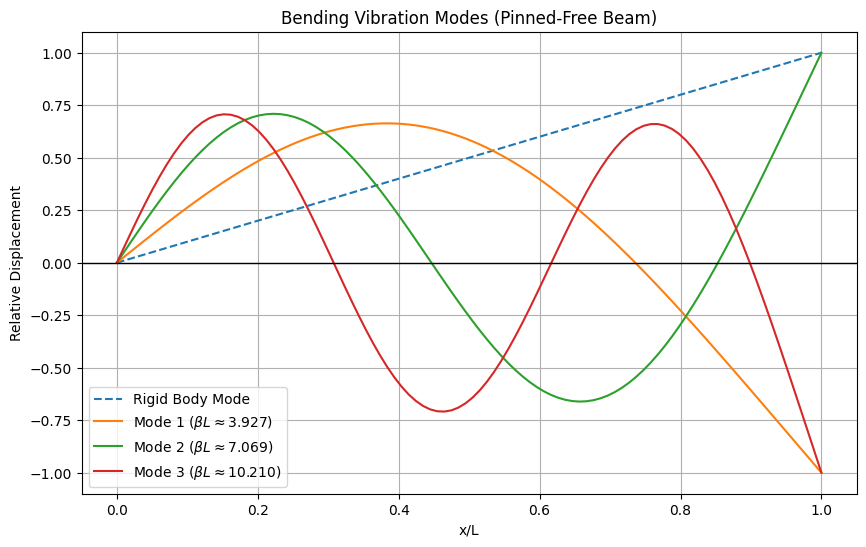

前三个非零特征值 beta*L: [np.float64(3.9266023120479185), np.float64(7.068582745628732), np.float64(10.210176122807573)]


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

# 定义频率方程 f(x) = tan(x) - tanh(x)
def frequency_equation(x):
    return np.tan(x) - np.tanh(x)

# 寻找根 (避开 tan 的渐近线)
# 第一个根是 0 (刚体模式)
# 后续根的初始猜想值
guesses = [3.926, 7.068, 10.210] 
roots = [fsolve(frequency_equation, g)[0] for g in guesses]

# 模态函数 Y(x)
# 根据边界条件 C = A * (sin(beta L) / sinh(beta L))
def mode_shape(x, beta_L, is_rigid=False):
    if is_rigid:
        return x / 1.0  # 归一化线性旋转
    C_over_A = np.sin(beta_L) / np.sinh(beta_L)
    return np.sin(beta_L * x) + C_over_A * np.sinh(beta_L * x)

x_vals = np.linspace(0, 1, 100)
plt.figure(figsize=(10, 6))

# 绘制刚体模态
plt.plot(x_vals, mode_shape(x_vals, 0, is_rigid=True), '--', label='Rigid Body Mode')

# 绘制前三个振动模态
for i, beta_L in enumerate(roots):
    y_vals = mode_shape(x_vals, beta_L)
    # 归一化处理以便观察
    y_vals /= np.max(np.abs(y_vals))
    plt.plot(x_vals, y_vals, label=f'Mode {i+1} ($\\beta L \\approx {beta_L:.3f}$)')

plt.axhline(0, color='black', lw=1)
plt.title('Bending Vibration Modes (Pinned-Free Beam)')
plt.xlabel('x/L')
plt.ylabel('Relative Displacement')
plt.legend()
plt.grid(True)
plt.show()

# 打印特征值
print(f"前三个非零特征值 beta*L: {roots}")